# 07221203_2025 — dump 1 noise-pulse survey

Series `07221203_2025`, dump `F0001` (Run76: Side2, PuBe/Pb&poly lead-stack/borax,
-83.2 V). Picking out clean noise traces on **Detector 0, Channel 0 only** as a starting
point for a PSD study. Run with the `darkmatter_cli_env` conda environment.

Uses the shared `python/` library (`pulse_io`/`pulse_quantities`/`pulse_cuts`) instead
of ad-hoc per-trace loops — see `python/README.md` for the conventions.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "python"))

from nsdf_dark_matter.idx import load_all_data

import numpy as np
import matplotlib.pyplot as plt

import pulse_io as pio
import pulse_quantities as pq
import pulse_cuts as pc
from pulse_config import PulseConfig

home_directory = Path.home()
series_path = str(home_directory) + '/idx/07221203_2025_F0001'
cdms = load_all_data(series_path)

detector_ids = cdms.get_detector_ids()
print(f"channel groups (detector_ids): {len(detector_ids)}")

### Note: leading-sample glitch

A number of traces have a brief electronic glitch (a step offset) in the first few
samples, before the real baseline settles — sampled 25 random traces and found leading
runs of 1-5 anomalous samples in several of them (relative to a robust estimate from
samples 200-1000), separate from the handful of traces with a genuine pulse/drift
extending much further in. `config.glitch_samples = 10` below skips that leading run
when computing the pretrigger `bmean`/`bstd` (via `pulse_quantities`), with margin. It
does **not** fix traces where the contamination is a real pulse spanning hundreds of
samples — that's a different, legitimate problem the cut still has to handle.

In [ ]:
DETECTOR = 0
CHANNEL = 0
config = PulseConfig(pretrigger_samples=1000, glitch_samples=10, sample_period_s=1.6e-6)
PRETRIGGER_SAMPLES = config.pretrigger_samples  # kept for readability in later cells

detector0_ids = pio.filter_by_detector(detector_ids, DETECTOR)
detector_id_arr, pulses = pio.load_channel_batch(cdms, detector0_ids, CHANNEL)

bmean_arr = pq.pretrigger_mean(pulses, config)
bstd_arr = pq.pretrigger_std(pulses, config)
dev_arr = pq.max_deviation(pulses, config)
ratio_arr = pq.excursion_ratio(pulses, config)

print(f"detector {DETECTOR}, channel {CHANNEL} traces: {len(detector_id_arr)}")

## Good noise selection

Cut, relative to Detector 0/Channel 0's own distribution: `bstd` below its 75th
percentile (quiet baseline) and `ratio = dev/bstd` below its 25th percentile (no
post-baseline excursion). `dev` is measured in the post-pretrigger region only (samples
1000-4096) — measuring it over the whole trace instead puts an artificial floor around
`ratio ~ 1` regardless of threshold.

In [ ]:
BSTD_CAP_PERCENTILE = 75
RATIO_THRESH_PERCENTILE = 25

good_mask = (
    pc.quiet_baseline(pulses, config, percentile=BSTD_CAP_PERCENTILE, bstd=bstd_arr)
    & pc.excursion_below_percentile(pulses, config, percentile=RATIO_THRESH_PERCENTILE, ratio=ratio_arr)
)

bstd_cap = np.percentile(bstd_arr[bstd_arr > 0], BSTD_CAP_PERCENTILE)
ratio_thresh = np.percentile(ratio_arr[np.isfinite(ratio_arr)], RATIO_THRESH_PERCENTILE)
print(f"bstd_cap={bstd_cap:.2f}, ratio_thresh={ratio_thresh:.2f}")
print(f"good noise traces: {good_mask.sum()} / {len(detector_id_arr)}")

good_detector_ids = detector_id_arr[good_mask]

In [4]:
from IPython.display import display, HTML
import csv

rows = []
for i in np.where(good_mask)[0]:
    detector_id = detector_id_arr[i]
    event_id, *_ = detector_id.split('_')
    rows.append({
        "event": event_id,
        "bstd": round(float(bstd_arr[i]), 3),
        "dev": round(float(dev_arr[i]), 3),
        "ratio": round(float(ratio_arr[i]), 3),
    })
rows.sort(key=lambda r: int(r["event"]))

csv_path = "good_noise_det0_ch0.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print(f"saved {len(rows)} rows to {csv_path} (previewing first 10 below)\n")

html = ["<table><tr>" + "".join(f"<th>{k}</th>" for k in rows[0].keys()) + "</tr>"]
for r in rows[:10]:
    html.append("<tr>" + "".join(f"<td>{v}</td>" for v in r.values()) + "</tr>")
html.append("</table>")
display(HTML("".join(html)))

saved 41 rows to good_noise_det0_ch0.csv (previewing first 10 below)



event,bstd,dev,ratio
10085,16.583,29.917,1.804
10347,29.67,41.076,1.384
10431,11.149,16.396,1.471
10508,8.755,14.722,1.682
10529,13.768,21.672,1.574
10858,27.355,45.022,1.646
11083,16.459,19.988,1.214
11114,20.081,34.366,1.711
11141,17.963,25.804,1.436
11142,24.04,31.096,1.293


## Ratio histogram, `dev > 0` only

Same idea as the ratio histogram in `dump1_noise_pulses.ipynb`, but pre-removing any
trace with `dev == 0` first: `log10(ratio)` is `-inf` for those (there happen to be none
for Detector 0/Channel 0 in this dump, but the filter guards against it regardless).

detector 0, channel 0 traces with dev == 0 (excluded): 0


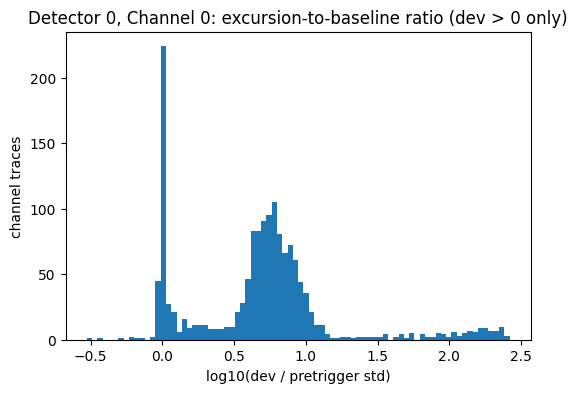

In [5]:
nonzero_dev = dev_arr > 0
print(f"detector {DETECTOR}, channel {CHANNEL} traces with dev == 0 (excluded): {(~nonzero_dev).sum()}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(ratio_arr[nonzero_dev]), bins=80)
ax.set_xlabel("log10(dev / pretrigger std)")
ax.set_ylabel("channel traces")
ax.set_title(f"Detector {DETECTOR}, Channel {CHANNEL}: excursion-to-baseline ratio (dev > 0 only)")
plt.show()

## Two populations from the histogram

The histogram above has a sharp narrow spike right at `log10(ratio) ~ 0` and a much
broader hump from about 0.5 to 1.0. Two cuts, one per feature:

- **Cut A — widened**: `log10(ratio)` in `[-0.05, 0.48)`, from the narrow near-zero spike
  out to just below where the broad peak starts (widened from the original `[-0.05, 0.05)`
  to test whether the near-zero traces' pulses really do all rise at the same time, or
  whether that was an artifact of too narrow a slice)
- **Cut B — broad peak**: `log10(ratio)` in `[0.5, 1.0]`

A few example traces from each, baseline-subtracted and overlaid, to see what these two
populations actually look like.

In [ ]:
log_ratio_arr = np.log10(ratio_arr)

cut_a_mask = nonzero_dev & (log_ratio_arr >= -0.05) & (log_ratio_arr < 0.48)
cut_b_mask = nonzero_dev & (log_ratio_arr >= 0.5) & (log_ratio_arr < 1.0)
cut_a_indices = np.where(cut_a_mask)[0]
cut_b_indices = np.where(cut_b_mask)[0]

print(f"cut A (widened, near zero to 0.48): {cut_a_mask.sum()} traces")
print(f"cut B (0.5 to 1.0):                 {cut_b_mask.sum()} traces")

rng = np.random.default_rng(0)
n_show = 8
cut_a_show = rng.choice(cut_a_indices, size=n_show, replace=False)
cut_b_show = rng.choice(cut_b_indices, size=n_show, replace=False)

In [ ]:
colors_a = plt.cm.tab10(np.linspace(0, 1, n_show))

fig, ax = plt.subplots(figsize=(9, 5))
for i, color in zip(cut_a_show, colors_a):
    trace = pulses[i] - bmean_arr[i]
    ax.plot(trace, linewidth=0.9, color=color,
             label=f"{detector_id_arr[i].split('_')[0]} (ratio={ratio_arr[i]:.2f})")
ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Cut A (widened): log10(ratio) in [-0.05, 0.48) — {n_show} example traces")
ax.legend(fontsize=7, ncol=2, loc="upper right", title="evt")
fig.tight_layout()
plt.show()

### Testing the hypothesis: does rise time track `ratio` across all of Cut A?

The suspicion: if these pulses have similar amplitude, then how much of the 1000-sample
pretrigger window a pulse contaminates determines `bstd` (more contamination -> larger
`bstd`), and `ratio = dev/bstd` for a fixed `dev` is then *smaller* the more of the
window got contaminated — i.e. smaller `ratio` should mean an *earlier* rise (more of
the pretrigger swallowed by the pulse), not a random sample of rise times. Estimate a
per-trace "rise sample" (first post-pretrigger sample where the trace crosses half of
its own `dev`) for every trace in the widened Cut A, not just the 8 shown above, and
plot rise sample vs. `ratio`.

In [ ]:
rise_samples = pq.rise_sample(pulses[cut_a_indices], config)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ratio_arr[cut_a_indices], rise_samples, s=12, alpha=0.6)
ax.set_xlabel("ratio")
ax.set_ylabel("estimated rise sample (half-max crossing)")
ax.set_title("Cut A (widened): rise sample vs. ratio")
fig.tight_layout()
plt.show()

corr = np.corrcoef(ratio_arr[cut_a_indices], rise_samples)[0, 1]
print(f"Pearson correlation (ratio, rise sample): {corr:.3f}")
print(f"rise sample range: {rise_samples.min()} to {rise_samples.max()}")

**Confirmed — the original narrow slice was hiding the spread, not revealing a real
clustering.** Correlation of 0.45 between `ratio` and rise sample, and rise samples
now span 1000 to 2698 (vs. everything piling up around sample 500-600 in the original
narrow `[-0.05, 0.05)` slice). The scatter has two components:

- A large group sitting exactly at `rise_sample = 1000` across a wide range of `ratio`
  (roughly 0.9 to 2.5). This is a floor artifact of the detection method, not a real
  clustering: these pulses already crossed half-max *before* sample 1000, inside the
  pretrigger window itself, so "first post-pretrigger crossing" reports the boundary
  rather than the true onset. These are exactly the fully-pretrigger-contaminated cases
  the earlier note described.
- A clear rising trend above that floor: traces with `ratio` from ~1.3 up to ~2.9 have
  rise samples spreading smoothly from ~1200 out to ~2700. For pulses of similar
  amplitude, less of the pretrigger window gets contaminated the later the pulse
  actually rises — smaller contamination means smaller `bstd`, which (for similar `dev`)
  means *larger* `ratio`. That's exactly the mechanism proposed, and it's what's in the
  data once the cut isn't narrow enough to hide it.

In [ ]:
colors_b = plt.cm.tab10(np.linspace(0, 1, n_show))

fig, ax = plt.subplots(figsize=(9, 5))
for i, color in zip(cut_b_show, colors_b):
    trace = pulses[i] - bmean_arr[i]
    ax.plot(trace, linewidth=0.9, color=color, label=f"{detector_id_arr[i].split('_')[0]}")
ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Cut B: log10(ratio) in [0.5, 1.0) — {n_show} example traces")
ax.legend(fontsize=7, ncol=4, loc="upper right", title="evt")
fig.tight_layout()
plt.show()

## This inverts the naive expectation — worth flagging

**Cut A (`ratio ~ 1`) is mostly *bad* traces, and Cut B (`ratio ~ 3-10`) is mostly
*good* ones — the opposite of what "smaller ratio = quieter" would suggest.**

Looking at the 8 examples above: 7-8 of 8 Cut A traces show an obvious real pulse (a
rise around sample 500-600 that decays over the rest of the trace), while most Cut B
traces look like flat, genuine noise. Why:

- `dev` is the *max* of ~3000 post-baseline samples. Even for pure Gaussian noise,
  extreme-value statistics put that max around 3-5x the noise's own std — so a
  genuinely quiet trace is *expected* to land around `ratio ~ 3-8` (Cut B), not `~1`.
- `ratio ~ 1` traces get there anomalously: their pretrigger window (used for `bstd`)
  already contains part of a pulse or a slow transition, inflating `bstd` enough that
  the post-baseline max deviation no longer stands out above it. The trace isn't quiet
  — its baseline estimate is just as contaminated as the rest of it.
- Skipping the leading-sample electronic glitch (`GLITCH_SAMPLES = 10`, above) does
  **not** fix Cut A — confirmed by re-running after adding that fix. These traces have a
  real pulse spanning hundreds of samples, not a brief startup artifact, so no amount of
  leading-edge trimming removes the contamination.

**This means the current "good noise" cut (`ratio < 25th percentile` ≈ 1.93) is biased
toward exactly the wrong population** — it favors low-ratio traces like Cut A over the
high-ratio-but-actually-quiet traces in Cut B. `BASELINE_STD_CAP` was meant to guard
against this, but evidently doesn't fully separate it here. Worth revisiting: e.g.
requiring `ratio` to be *in* a band around the extreme-value expectation (say 2-8)
rather than simply below a percentile, so Cut-A-like contaminated traces get excluded
instead of preferentially selected.